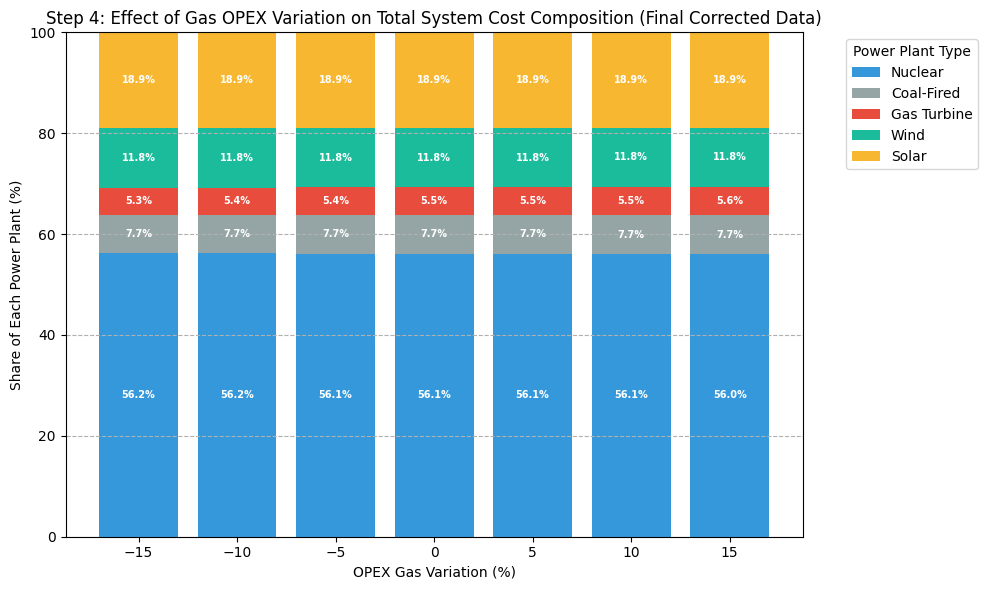

In [8]:
import numpy as np
import matplotlib.pyplot as plt


costs_base_new = {
    'Nuclear': 995461242,
    'Coal-Fired': 136454726,
    'Gas Turbine': 96865208,
    'Wind': 209825104,
    'Solar': 335693759
}

gas_opex_base_new = 16162208

total_system_cost_base_new = sum(costs_base_new.values())


opex_variation = np.arange(-15, 20, 5)
scenarios = {}

for var in opex_variation:
    new_gas_opex = gas_opex_base_new * (1 + var / 100)

    gas_capex = costs_base_new['Gas Turbine'] - gas_opex_base_new

    new_gas_total_cost = gas_capex + new_gas_opex
    new_system_cost = total_system_cost_base_new - costs_base_new['Gas Turbine'] + new_gas_total_cost

    scenarios[var] = {
        'Nuclear': (costs_base_new['Nuclear'] / new_system_cost) * 100,
        'Coal-Fired': (costs_base_new['Coal-Fired'] / new_system_cost) * 100,
        'Gas Turbine': (new_gas_total_cost / new_system_cost) * 100,
        'Wind': (costs_base_new['Wind'] / new_system_cost) * 100,
        'Solar': (costs_base_new['Solar'] / new_system_cost) * 100
    }

fig, ax = plt.subplots(figsize=(10, 6))

technologies = ['Nuclear', 'Coal-Fired', 'Gas Turbine', 'Wind', 'Solar']
bottoms = np.zeros(len(opex_variation))

colors = {
    'Nuclear': '#3498db',
    'Coal-Fired': '#95a5a6',
    'Gas Turbine': '#e74c3c',
    'Wind': '#1abc9c',
    'Solar': '#f7b731'
}


bar_width = 4.0

for tech in technologies:
    shares = [scenarios[var][tech] for var in opex_variation]

    ax.bar(opex_variation, shares, bottom=bottoms, label=tech, color=colors.get(tech), width=bar_width)

    for i, var in enumerate(opex_variation):
        share_value = shares[i]

        if share_value > 2.0:
            text_y_position = bottoms[i] + share_value / 2

            ax.text(var, text_y_position,
                    f'{share_value:.1f}%',
                    ha='center', va='center', fontsize=7, color='white', fontweight='bold')

    bottoms += shares


ax.set_ylabel('Share of Each Power Plant (%)')
ax.set_xlabel('OPEX Gas Variation (%)')
ax.set_title('Step 4: Effect of Gas OPEX Variation on Total System Cost Composition (Final Corrected Data)')
ax.set_xticks(opex_variation)
ax.set_ylim(0, 100)
ax.legend(title="Power Plant Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()